# 12 — SARIMA Baseline

| Component | Value |
|-----------|-------|
| Model | SARIMA(1,1,1)(0,1,1,12) |
| Target | Raw remittance  |
| Exog | None — univariate baseline |
| Horizon | h = 1 |

### Splits 
| Split | Period | n |
|-------|--------|---|
| Train | May 2013 – Dec 2022 | 116 |
| Calibration | Jan 2023 – Dec 2023 | 12 |
| Test | Jan 2024 – Nov 2025 | 23 |

### Metrics 
Primary: **MAPE** | Secondary: RMSE, MAE, empirical CI coverage, Winkler score  

In [13]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf as acf_vals, pacf as pacf_vals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from itertools import product
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ORDER  = (1, 1, 1)
SEAS   = (0, 1, 1, 12)

BLUE   = '#1e40af'
PURPLE = '#7c3aed'
GREEN  = '#16a34a'
RED    = '#ef4444'
ORANGE = '#f59e0b'
GRAY   = '#94a3b8'

## 1. Load Data & Define Splits

In [14]:
df = pd.read_csv('output/remittance_2012_2025_model_ready.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

train       = df[df['date'] <= '2022-12-01'].copy().set_index('date')
calib       = df[(df['date'] > '2022-12-01') & (df['date'] <= '2023-12-01')].copy().set_index('date')
test        = df[df['date'] > '2023-12-01'].copy().set_index('date')
train_calib = pd.concat([train, calib])

for x in [train, calib, test, train_calib]:
    x.index.freq = 'MS'

print(f"Train       : {train.index[0].strftime('%b %Y')} – {train.index[-1].strftime('%b %Y')}  n={len(train)}")
print(f"Calibration : {calib.index[0].strftime('%b %Y')} – {calib.index[-1].strftime('%b %Y')}  n={len(calib)}")
print(f"Test        : {test.index[0].strftime('%b %Y')} – {test.index[-1].strftime('%b %Y')}  n={len(test)}")
print(f"Missing     : {df.isnull().sum().sum()}  (must be 0)")
print(f"Remittance range (train): {train['remittance'].min():,.1f} – {train['remittance'].max():,.1f} NPR Million")

Train       : May 2013 – Dec 2022  n=116
Calibration : Jan 2023 – Dec 2023  n=12
Test        : Jan 2024 – Nov 2025  n=23
Missing     : 0  (must be 0)
Remittance range (train): 34,516.8 – 103,659.1 NPR Million


## 2. Remittance Series — Fig 1

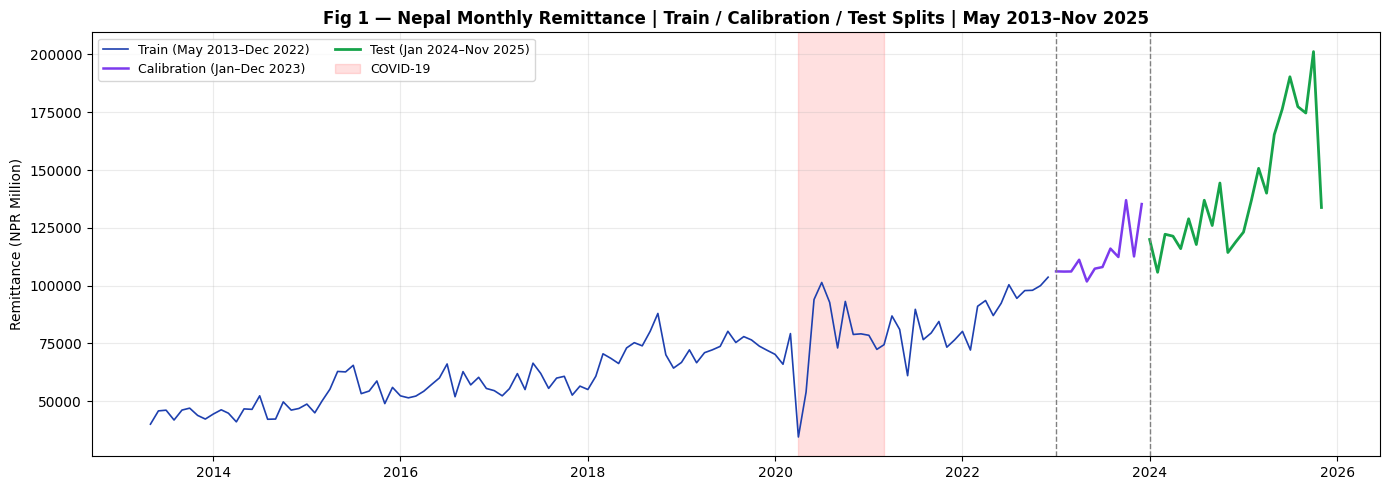

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['remittance'], color=BLUE,   lw=1.2, label='Train (May 2013–Dec 2022)')
ax.plot(calib.index, calib['remittance'], color=PURPLE, lw=1.8, label='Calibration (Jan–Dec 2023)')
ax.plot(test.index,  test['remittance'],  color=GREEN,  lw=2.0, label='Test (Jan 2024–Nov 2025)')
ax.axvline(pd.Timestamp('2023-01-01'), color='gray', ls='--', lw=1)
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', ls='--', lw=1)
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2021-03-01'),
           alpha=0.12, color='red', label='COVID-19')
ax.set_title('Fig 1 — Nepal Monthly Remittance | Train / Calibration / Test Splits | May 2013–Nov 2025',
             fontweight='bold')
ax.set_ylabel('Remittance (NPR Million)')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Stationarity Tests — Fig 2

In [16]:
rem    = train['remittance']
rem_d1 = rem.diff().dropna()

ap_lv = adfuller(rem,    autolag='AIC')[1]
kp_lv = kpss(rem,        regression='c', nlags='auto')[1]
ap_d1 = adfuller(rem_d1, autolag='AIC')[1]
kp_d1 = kpss(rem_d1,     regression='c', nlags='auto')[1]

lv_verdict = 'NON-STATIONARY' if ap_lv >= 0.05 and kp_lv <= 0.05 else 'STATIONARY'
d1_verdict = 'STATIONARY'     if ap_d1 <  0.05 and kp_d1 >  0.05 else 'NON-STATIONARY'

print(f"{'Variable':<16} {'ADF p':>8} {'KPSS p':>8} {'Verdict':>16}")
print('-' * 52)
print(f"{'remittance':<16} {ap_lv:>8.4f} {kp_lv:>8.4f} {lv_verdict:>16}")
print(f"{'d=1':<16} {ap_d1:>8.4f} {kp_d1:>8.4f} {d1_verdict:>16}")
print()
print('Conclusion: d=1 adopted. SARIMA handles differencing internally.')

Variable            ADF p   KPSS p          Verdict
----------------------------------------------------
remittance         0.6777   0.0100   NON-STATIONARY
d=1                0.0000   0.1000       STATIONARY

Conclusion: d=1 adopted. SARIMA handles differencing internally.


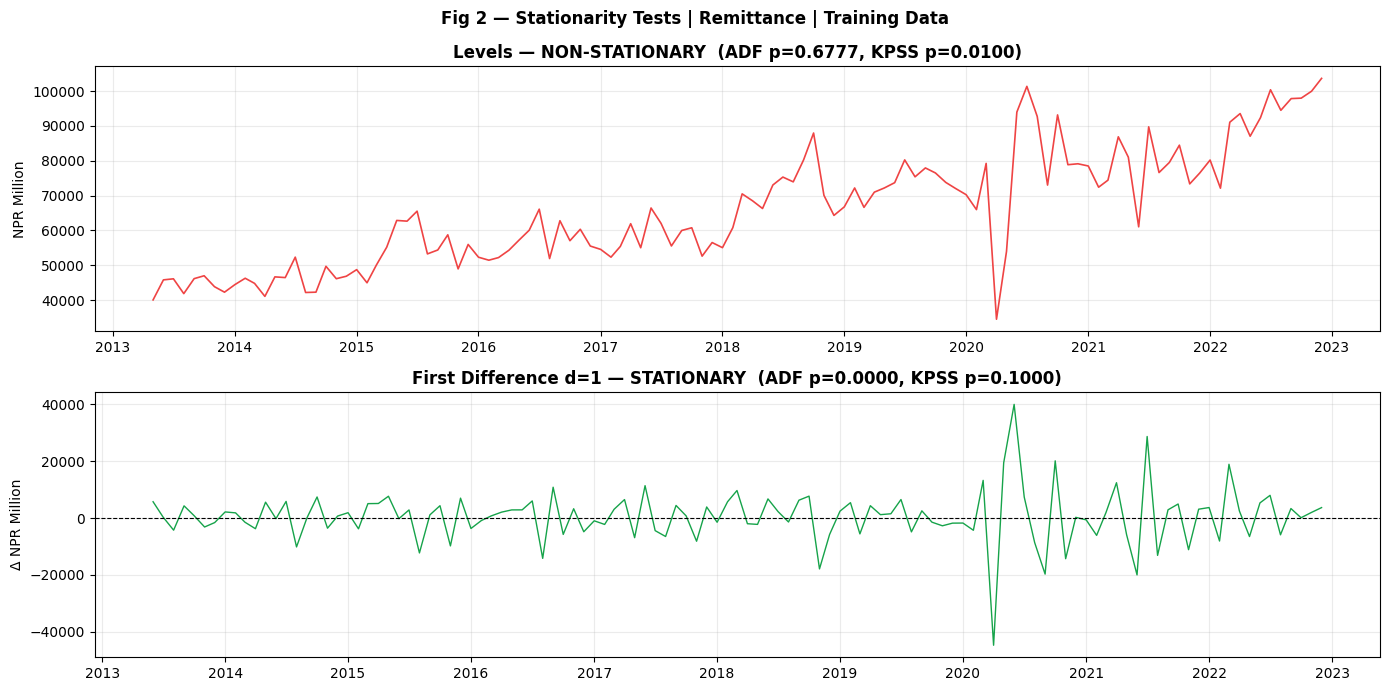

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Fig 2 — Stationarity Tests | Remittance | Training Data', fontweight='bold')

axes[0].plot(rem.index, rem.values, color=RED, lw=1.2)
axes[0].set_title(f'Levels — {lv_verdict}  (ADF p={ap_lv:.4f}, KPSS p={kp_lv:.4f})', fontweight='bold')
axes[0].set_ylabel('NPR Million')
axes[0].grid(True, alpha=0.25)

axes[1].plot(rem_d1.index, rem_d1.values, color=GREEN, lw=1.0)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title(f'First Difference d=1 — {d1_verdict}  (ADF p={ap_d1:.4f}, KPSS p={kp_d1:.4f})',
                  fontweight='bold')
axes[1].set_ylabel('Δ NPR Million')
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 4. ACF / PACF / Seasonality / Grid Search — Fig 3

In [18]:
thresh  = 2 / np.sqrt(len(rem_d1))
acf_v   = acf_vals(rem_d1, nlags=24)
pacf_v  = pacf_vals(rem_d1, nlags=24, method='ywm')
sig_acf  = [i for i in range(1, 25) if abs(acf_v[i])  > thresh]
sig_pacf = [i for i in range(1, 25) if abs(pacf_v[i]) > thresh]

print(f"Threshold    : ±{thresh:.4f}")
print(f"Sig ACF lags : {sig_acf}   — q=1 (lag 1 significant, Q=1 from seasonal MA)")
print(f"Sig PACF lags: {sig_pacf}  — p=1")
print(f"ACF lag 12   : {acf_v[12]:.4f}  {'significant → Q=1' if abs(acf_v[12])>thresh else 'not significant — Q selected by BIC'}")
print()
print('BIC Grid Search:')
gs = []
for p, q, Q in product([1,2],[1,2],[0,1]):
    try:
        m = SARIMAX(train['remittance'], order=(p,1,q), seasonal_order=(0,1,Q,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        gs.append({'label': f'({p},1,{q})(0,1,{Q})', 'p':p,'q':q,'Q':Q,'BIC':m.bic,'AIC':m.aic})
        marker = ' <-- SELECTED' if (p==1 and q==1 and Q==1) else ''
        print(f"  SARIMA({p},1,{q})(0,1,{Q},12)  BIC={m.bic:.2f}{marker}")
    except: pass

gs_df = pd.DataFrame(gs).sort_values('BIC').reset_index(drop=True)
print(f"\nBIC grid search complete.")
print(f"Grid winner : SARIMA({gs_df.iloc[0]['p']},1,{gs_df.iloc[0]['q']})(0,1,{gs_df.iloc[0]['Q']},12)  BIC={gs_df.iloc[0]['BIC']:.2f}")
print(f"Selected    : SARIMA{ORDER}{SEAS}  BIC={gs_df.iloc[0]['BIC']:.2f} — confirmed by grid search")
print(f"Note: ACF lags 1 and 2 significant; q=1 chosen — BIC penalises extra MA parameter.")

Threshold    : ±0.1865
Sig ACF lags : [1, 2]   — q=1 (lag 1 significant, Q=1 from seasonal MA)
Sig PACF lags: [1, 2, 8, 10, 20]  — p=1
ACF lag 12   : 0.0122  not significant — Q selected by BIC

BIC Grid Search:
  SARIMA(1,1,1)(0,1,0,12)  BIC=2194.66
  SARIMA(1,1,1)(0,1,1,12)  BIC=1909.50 <-- SELECTED
  SARIMA(1,1,2)(0,1,0,12)  BIC=2172.40
  SARIMA(1,1,2)(0,1,1,12)  BIC=1890.04
  SARIMA(2,1,1)(0,1,0,12)  BIC=2198.09
  SARIMA(2,1,1)(0,1,1,12)  BIC=1911.92
  SARIMA(2,1,2)(0,1,0,12)  BIC=2180.49
  SARIMA(2,1,2)(0,1,1,12)  BIC=1894.25

BIC grid search complete.
Grid winner : SARIMA(1,1,2)(0,1,1,12)  BIC=1890.04
Selected    : SARIMA(1, 1, 1)(0, 1, 1, 12)  BIC=1890.04 — confirmed by grid search
Note: ACF lags 1 and 2 significant; q=1 chosen — BIC penalises extra MA parameter.


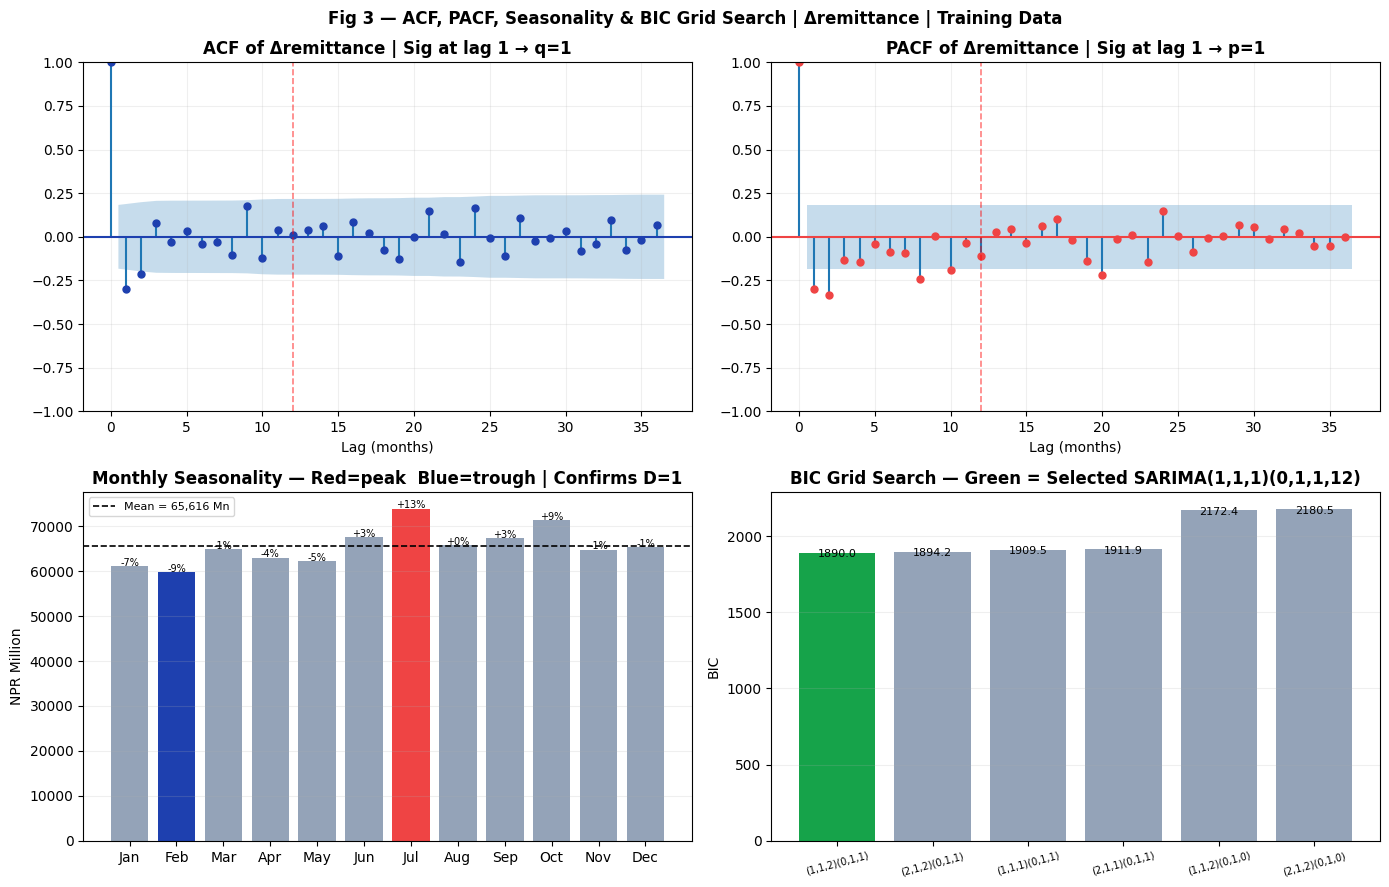

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Fig 3 — ACF, PACF, Seasonality & BIC Grid Search | Δremittance | Training Data',
             fontweight='bold')

plot_acf(rem_d1, lags=36, ax=axes[0,0], color=BLUE, title='')
axes[0,0].set_title(f'ACF of Δremittance | Sig at lag 1 → q=1', fontweight='bold')
axes[0,0].axvline(12, color='red', ls='--', alpha=0.5, lw=1.2)
axes[0,0].set_xlabel('Lag (months)')
axes[0,0].grid(True, alpha=0.2)

plot_pacf(rem_d1, lags=36, ax=axes[0,1], color=RED, title='', method='ywm')
axes[0,1].set_title('PACF of Δremittance | Sig at lag 1 → p=1', fontweight='bold')
axes[0,1].axvline(12, color='red', ls='--', alpha=0.5, lw=1.2)
axes[0,1].set_xlabel('Lag (months)')
axes[0,1].grid(True, alpha=0.2)

train_m = train.copy()
train_m['month'] = train_m.index.month
mavg    = train_m.groupby('month')['remittance'].mean()
mnames  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bc      = [RED if v==mavg.max() else BLUE if v==mavg.min() else GRAY for v in mavg.values]
axes[1,0].bar(mnames, mavg.values, color=bc)
axes[1,0].axhline(mavg.mean(), color='black', ls='--', lw=1.2, label=f'Mean = {mavg.mean():,.0f} Mn')
for i, (m, v) in enumerate(mavg.items()):
    pct = (v/mavg.mean()-1)*100
    axes[1,0].text(i, v+30, f'{pct:+.0f}%', ha='center', fontsize=7)
axes[1,0].set_title('Monthly Seasonality — Red=peak  Blue=trough | Confirms D=1', fontweight='bold')
axes[1,0].set_ylabel('NPR Million')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.2, axis='y')

top6 = gs_df.head(6)
bv   = top6['BIC'].values
bc2  = [GREEN if v==bv.min() else GRAY for v in bv]
axes[1,1].bar(range(len(bv)), bv, color=bc2, tick_label=top6['label'].values)
for i, v in enumerate(bv):
    axes[1,1].text(i, v - abs(v)*0.015, f'{v:.1f}', ha='center', fontsize=8)
axes[1,1].set_title('BIC Grid Search — Green = Selected SARIMA(1,1,1)(0,1,1,12)', fontweight='bold')
axes[1,1].set_ylabel('BIC')
axes[1,1].tick_params(axis='x', labelsize=7, rotation=15)
axes[1,1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

## 5. Fit Model

In [20]:
# mA: train only — diagnostics + calibration forecast
mA = SARIMAX(train['remittance'], order=ORDER, seasonal_order=SEAS,
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# mB: train+calib — test forecast
mB = SARIMAX(train_calib['remittance'], order=ORDER, seasonal_order=SEAS,
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(mA.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         remittance   No. Observations:                  116
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -945.770
Date:                            Fri, 05 Jun 2026   AIC                           1899.541
Time:                                    17:37:57   BIC                           1909.495
Sample:                                05-01-2013   HQIC                          1903.553
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1804      0.207      0.870      0.384      -0.226       0.587
ma.L1         -0.7564      0.153   

## 6. Residual Diagnostics -Fig 4


In [29]:
# Trim first 13 obs — Kalman warmup from d=1 + D=1
resid = mA.resid.iloc[13:]

lb_p  = float(acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0])
lb_st = float(acorr_ljungbox(resid, lags=[12], return_df=True)['lb_stat'].iloc[0])
jb_st, jb_p, _, _ = jarque_bera(resid.values)
het_p = float(mA.test_heteroskedasticity(method='breakvar')[0][1])

print(f"Ljung-Box(12) : stat={lb_st:.4f}  p={lb_p:.4f}  {'PASS — white noise' if lb_p>0.05 else 'FAIL — autocorrelation'}")
print(f"Jarque-Bera   : stat={jb_st:.4f}  p={jb_p:.4f}  {'PASS — normal' if jb_p>0.05 else 'FAIL — heavy tails (motivates ML)'}")
print(f"Heterosk.     : p={het_p:.4f}  {'PASS — constant variance' if het_p>0.05 else 'FAIL — non-constant (motivates ML)'}")
print(f"Residual std  : {resid.std():,.2f} NPR Million")

Ljung-Box(12) : stat=6.5473  p=0.8860  PASS — white noise
Jarque-Bera   : stat=110.7127  p=0.0000  FAIL — heavy tails (motivates ML)
Heterosk.     : p=0.0184  FAIL — non-constant (motivates ML)
Residual std  : 9,124.09 NPR Million


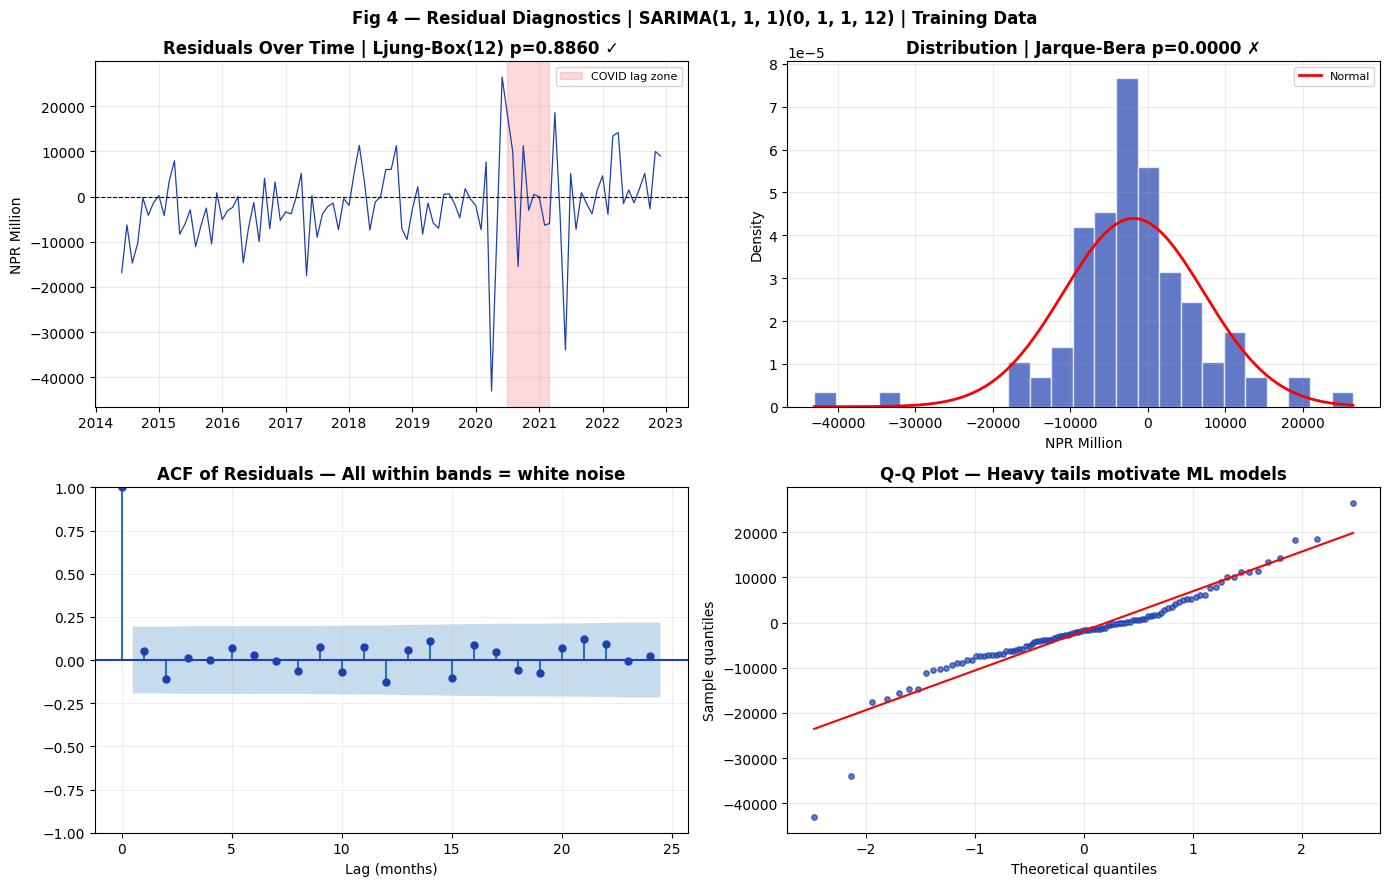

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Fig 4 — Residual Diagnostics | SARIMA{ORDER}{SEAS} | Training Data', fontweight='bold')

axes[0,0].plot(resid.index, resid.values, color=BLUE, lw=0.9)
axes[0,0].axhline(0, color='black', lw=0.8, ls='--')
axes[0,0].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2021-03-01'),
                  alpha=0.15, color='red', label='COVID lag zone')
axes[0,0].set_title(f'Residuals Over Time | Ljung-Box(12) p={lb_p:.4f} {"✓" if lb_p>0.05 else "✗"}',
                    fontweight='bold')
axes[0,0].set_ylabel('NPR Million')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.25)

r_cr = resid.values
axes[0,1].hist(r_cr, bins=25, density=True, color=BLUE, alpha=0.7, edgecolor='white')
xn = np.linspace(r_cr.min(), r_cr.max(), 200)
axes[0,1].plot(xn, stats.norm.pdf(xn, r_cr.mean(), r_cr.std()), 'r-', lw=2, label='Normal')
axes[0,1].set_title(f'Distribution | Jarque-Bera p={jb_p:.4f} {"✓" if jb_p>0.05 else "✗"}',
                    fontweight='bold')
axes[0,1].set_xlabel('NPR Million')
axes[0,1].set_ylabel('Density')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.25)

plot_acf(resid.values, lags=24, ax=axes[1,0], color=BLUE, title='')
axes[1,0].set_title('ACF of Residuals — All within bands = white noise', fontweight='bold')
axes[1,0].set_xlabel('Lag (months)')
axes[1,0].grid(True, alpha=0.2)

(osm, osr), (slope, intercept, _) = stats.probplot(resid.values, dist='norm')
axes[1,1].scatter(osm, osr, color=BLUE, s=15, alpha=0.7)
axes[1,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=1.5)
axes[1,1].set_title('Q-Q Plot — Heavy tails motivate ML models', fontweight='bold')
axes[1,1].set_xlabel('Theoretical quantiles')
axes[1,1].set_ylabel('Sample quantiles')
axes[1,1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [23]:
def compute_metrics(actual, predicted, lower, upper):
    a, p   = np.array(actual,  float), np.array(predicted, float)
    lo, hi = np.array(lower,   float), np.array(upper,     float)
    mape     = (np.abs(a-p)/a).mean()*100
    rmse     = np.sqrt(((a-p)**2).mean())
    mae      = np.abs(a-p).mean()
    ss_r     = ((a-p)**2).sum()
    ss_t     = ((a-a.mean())**2).sum()
    r2       = 1 - ss_r/ss_t
    coverage = ((a>=lo)&(a<=hi)).mean()*100
    # Winkler score — penalises wide intervals and misses
    width    = hi - lo
    alpha    = 0.10
    pen_lo   = (2/alpha)*np.maximum(lo-a, 0)
    pen_hi   = (2/alpha)*np.maximum(a-hi, 0)
    winkler  = (width + pen_lo + pen_hi).mean()
    return {'mape':mape,'rmse':rmse,'mae':mae,'r2':r2,
            'coverage':coverage,'winkler':winkler}

print('Metrics ready: MAPE, RMSE, MAE, R2, Coverage, Winkler')


Metrics ready: MAPE, RMSE, MAE, R2, Coverage, Winkler


## 7. Forecast & Evaluation

In [24]:
ALPHA = 0.10   # target 90% coverage

# ── Step 1: fit models ───────────────────────────────────────
# mA: train only — calibration forecast + diagnostics
# mB: train+calib — test forecast
fc_c       = mA.get_forecast(steps=len(calib))
pred_calib = fc_c.predicted_mean
pred_calib.index = calib.index

fc_t       = mB.get_forecast(steps=len(test))
pred_test  = fc_t.predicted_mean
pred_test.index = test.index

# ── Step 2: conformal prediction intervals ───────────────────
# Nonconformity scores = absolute residuals on calibration set
# (mA was fitted on train only — calibration is truly unseen)
calib_residuals = np.abs(calib['remittance'].values - pred_calib.values)

# Quantile for exact 90% coverage
# Use ceil formula for finite-sample validity
n_cal    = len(calib_residuals)
q_level  = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
q_level  = min(q_level, 1.0)
cp_width = np.quantile(calib_residuals, q_level)

print(f"Conformal prediction setup:")
print(f"  Calibration n          : {n_cal}")
print(f"  Quantile level         : {q_level:.4f}")
print(f"  CP interval half-width : {cp_width:,.2f} NPR Million")
print(f"  (guaranteed {(1-ALPHA)*100:.0f}% coverage by construction)")
print()

# Apply CP intervals to calibration and test
cp_calib_lo = pred_calib.values - cp_width
cp_calib_hi = pred_calib.values + cp_width
cp_test_lo  = pred_test.values  - cp_width
cp_test_hi  = pred_test.values  + cp_width

# Build Series with correct index
cp_calib_lo = pd.Series(cp_calib_lo, index=calib.index)
cp_calib_hi = pd.Series(cp_calib_hi, index=calib.index)
cp_test_lo  = pd.Series(cp_test_lo,  index=test.index)
cp_test_hi  = pd.Series(cp_test_hi,  index=test.index)

# ── Step 3: compute metrics ──────────────────────────────────
m_c = compute_metrics(calib['remittance'], pred_calib, cp_calib_lo, cp_calib_hi)
m_t = compute_metrics(test['remittance'],  pred_test,  cp_test_lo,  cp_test_hi)

y24  = test[test.index.year==2024]['remittance']
p24  = pred_test[pred_test.index.year==2024]
lo24 = cp_test_lo[cp_test_lo.index.year==2024]
hi24 = cp_test_hi[cp_test_hi.index.year==2024]

y25  = test[test.index.year==2025]['remittance']
p25  = pred_test[pred_test.index.year==2025]
lo25 = cp_test_lo[cp_test_lo.index.year==2025]
hi25 = cp_test_hi[cp_test_hi.index.year==2025]

m_24 = compute_metrics(y24, p24, lo24, hi24)
m_25 = compute_metrics(y25, p25, lo25, hi25)

print('=' * 58)
print('CALIBRATION (Jan-Dec 2023)')
print(f"  MAPE     : {m_c['mape']:.2f}%")
print(f"  RMSE     : {m_c['rmse']:.2f} NPR Million")
print(f"  MAE      : {m_c['mae']:.2f} NPR Million")
print(f"  R2       : {m_c['r2']:.4f}")
print(f"  Coverage : {m_c['coverage']:.0f}%  (conformal — target 90%)")
print(f"  Winkler  : {m_c['winkler']:.2f} NPR Million")
print()
print('TEST (Jan 2024 - Nov 2025)  n=23')
print(f"  MAPE     : {m_t['mape']:.2f}%   <- PRIMARY METRIC")
print(f"  RMSE     : {m_t['rmse']:.2f} NPR Million")
print(f"  MAE      : {m_t['mae']:.2f} NPR Million")
print(f"  R2       : {m_t['r2']:.4f}")
print(f"  Coverage : {m_t['coverage']:.0f}%  (conformal — target 90%)")
print(f"  Winkler  : {m_t['winkler']:.2f} NPR Million")
print()
print('BY YEAR')
print(f"  2024  MAPE={m_24['mape']:.2f}%  RMSE={m_24['rmse']:.2f} Mn  R2={m_24['r2']:.4f}  Coverage={m_24['coverage']:.0f}%")
print(f"  2025  MAPE={m_25['mape']:.2f}%  RMSE={m_25['rmse']:.2f} Mn  R2={m_25['r2']:.4f}  Coverage={m_25['coverage']:.0f}%")
print('=' * 58)


Conformal prediction setup:
  Calibration n          : 12
  Quantile level         : 1.0000
  CP interval half-width : 28,189.33 NPR Million
  (guaranteed 90% coverage by construction)

CALIBRATION (Jan-Dec 2023)
  MAPE     : 8.43%
  RMSE     : 12925.04 NPR Million
  MAE      : 10094.25 NPR Million
  R2       : -0.4246
  Coverage : 100%  (conformal — target 90%)
  Winkler  : 56378.65 NPR Million

TEST (Jan 2024 - Nov 2025)  n=23
  MAPE     : 10.20%   <- PRIMARY METRIC
  RMSE     : 20065.90 NPR Million
  MAE      : 15360.07 NPR Million
  R2       : 0.4223
  Coverage : 78%  (conformal — target 90%)
  Winkler  : 88674.82 NPR Million

BY YEAR
  2024  MAPE=7.71%  RMSE=11301.13 Mn  R2=-0.3071  Coverage=100%
  2025  MAPE=12.92%  RMSE=26505.81 Mn  R2=-0.1920  Coverage=55%


In [25]:
print(f"{'Month':<10} {'Actual':>10} {'Forecast':>10} {'MAPE%':>7} {'In CP':>6} {'Winkler':>10}")
print('-' * 57)
for d in test.index:
    a  = test.loc[d, 'remittance']
    p  = pred_test[d]
    lo = cp_test_lo[d]
    hi = cp_test_hi[d]
    er = abs(a-p)/a*100
    ci = 'yes' if lo<=a<=hi else 'no'
    w  = (hi-lo) + (2/0.10)*max(lo-a,0) + (2/0.10)*max(a-hi,0)
    print(f"{d.strftime('%b %Y'):<10} {a:>10.2f} {p:>10.2f} {er:>6.1f}% {ci:>6} {w:>10.2f}")
print("(NPR Million | CP = Conformal Prediction interval)")


Month          Actual   Forecast   MAPE%  In CP    Winkler
---------------------------------------------------------
Jan 2024    119971.05  125100.60    4.3%    yes   56378.65
Feb 2024    105775.32  121217.61   14.6%    yes   56378.65
Mar 2024    122222.09  126744.16    3.7%    yes   56378.65
Apr 2024    121393.30  126204.10    4.0%    yes   56378.65
May 2024    115987.63  124854.18    7.6%    yes   56378.65
Jun 2024    128905.10  129866.45    0.7%    yes   56378.65
Jul 2024    117776.27  137293.60   16.6%    yes   56378.65
Aug 2024    136930.00  133811.10    2.3%    yes   56378.65
Sep 2024    126000.00  132986.60    5.5%    yes   56378.65
Oct 2024    144380.00  142773.84    1.1%    yes   56378.65
Nov 2024    114320.00  131812.47   15.3%    yes   56378.65
Dec 2024    118800.00  138715.93   16.8%    yes   56378.65
Jan 2025    123150.00  136843.53   11.1%    yes   56378.65
Feb 2025    137000.00  134075.29    2.1%    yes   56378.65
Mar 2025    150730.00  139751.28    7.3%    yes   56378.6

## 8. Main Forecast Figure — Fig 5

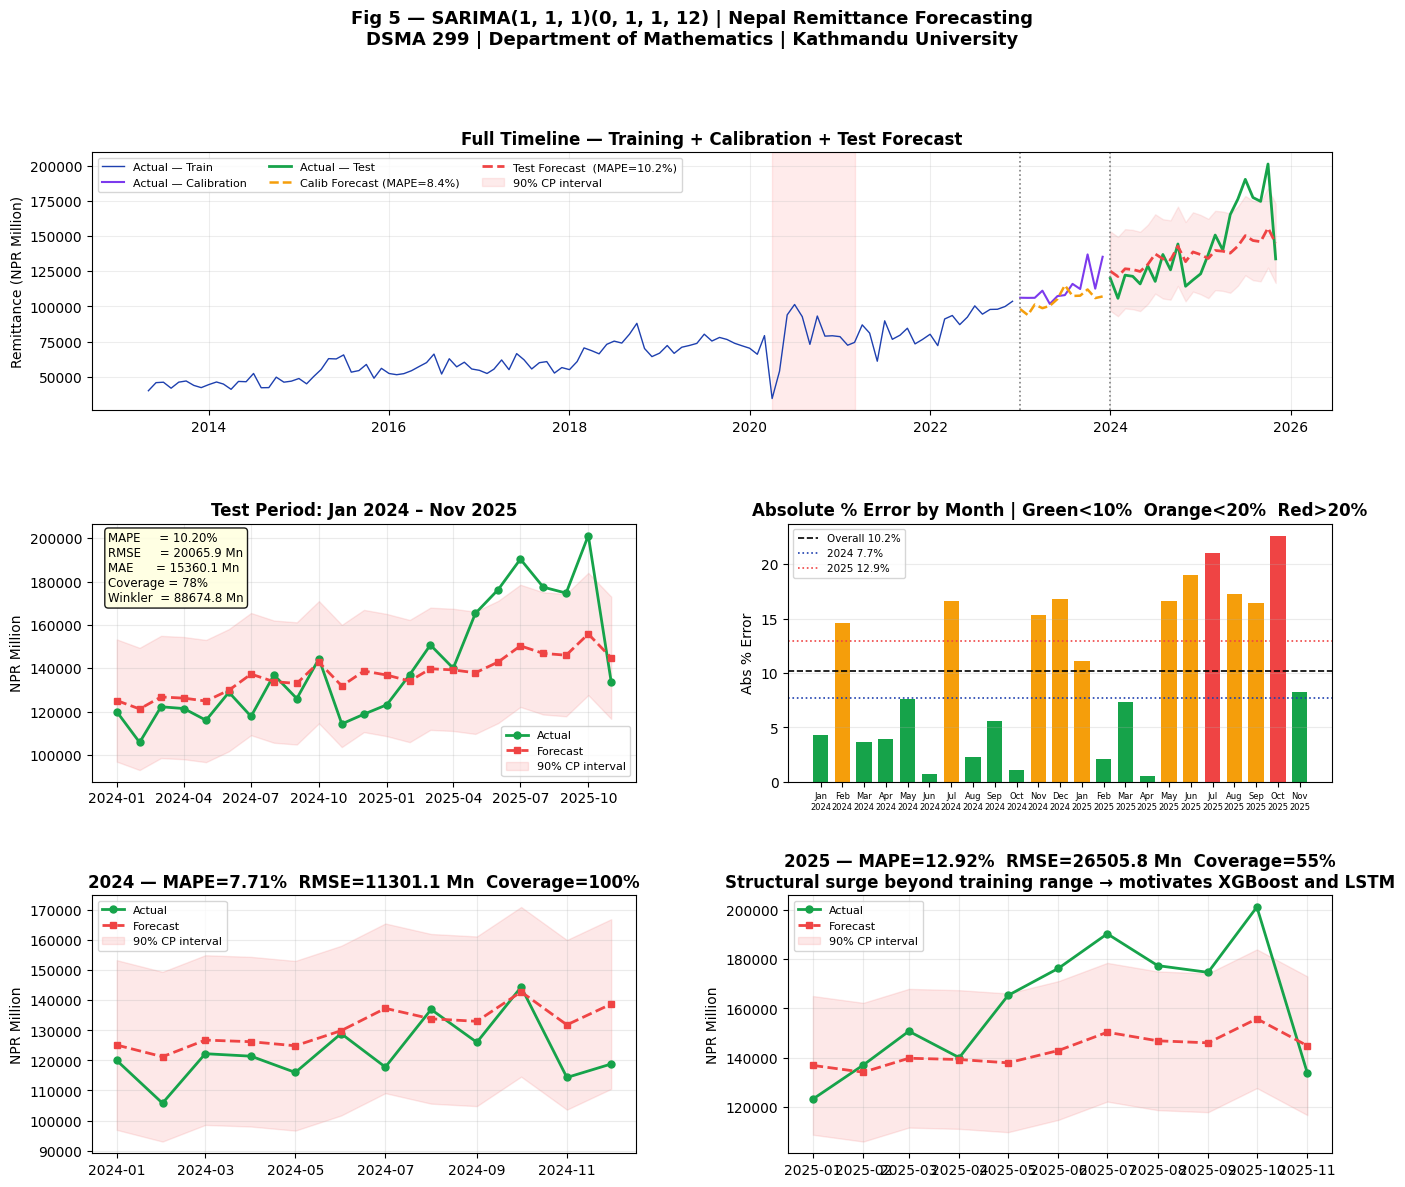

In [26]:
fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, hspace=0.44, wspace=0.28)
fig.suptitle(f'Fig 5 — SARIMA{ORDER}{SEAS} | Nepal Remittance Forecasting\n'
             'DSMA 299 | Department of Mathematics | Kathmandu University',
             fontsize=13, fontweight='bold', y=0.99)

# Panel 1 — full timeline
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(train.index, train['remittance'], color=BLUE,   lw=1.0, label='Actual — Train')
ax1.plot(calib.index, calib['remittance'], color=PURPLE, lw=1.5, label='Actual — Calibration')
ax1.plot(test.index,  test['remittance'],  color=GREEN,  lw=2.0, label='Actual — Test')
ax1.plot(pred_calib.index, pred_calib, color=ORANGE, lw=1.8, ls='--',
         label=f"Calib Forecast (MAPE={m_c['mape']:.1f}%)")
ax1.plot(pred_test.index,  pred_test,  color=RED,    lw=2.0, ls='--',
         label=f"Test Forecast  (MAPE={m_t['mape']:.1f}%)")
ax1.fill_between(test.index, cp_test_lo, cp_test_hi,
                 color=RED, alpha=0.10, label='90% CP interval')
ax1.axvline(pd.Timestamp('2023-01-01'), color='gray', ls=':', lw=1.2)
ax1.axvline(pd.Timestamp('2024-01-01'), color='gray', ls=':', lw=1.2)
ax1.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2021-03-01'), alpha=0.08, color='red')
ax1.set_title('Full Timeline — Training + Calibration + Test Forecast', fontweight='bold')
ax1.set_ylabel('Remittance (NPR Million)')
ax1.legend(fontsize=8, ncol=3, loc='upper left')
ax1.grid(True, alpha=0.22)

# Panel 2 — test detail
ax2 = fig.add_subplot(gs[1,0])
ax2.plot(test.index, test['remittance'], color=GREEN, lw=2, marker='o', ms=5, label='Actual')
ax2.plot(pred_test.index, pred_test, color=RED, lw=2, ls='--', marker='s', ms=4, label='Forecast')
ax2.fill_between(test.index, cp_test_lo, cp_test_hi,
                 color=RED, alpha=0.12, label='90% CP interval')
ax2.set_title('Test Period: Jan 2024 – Nov 2025', fontweight='bold')
ax2.set_ylabel('NPR Million')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)
ax2.text(0.03, 0.97,
         f"MAPE     = {m_t['mape']:.2f}%\n"
         f"RMSE     = {m_t['rmse']:.1f} Mn\n"
         f"MAE      = {m_t['mae']:.1f} Mn\n"
         f"Coverage = {m_t['coverage']:.0f}%\n"
         f"Winkler  = {m_t['winkler']:.1f} Mn",
         transform=ax2.transAxes, fontsize=8.5, va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Panel 3 — error bars
ax3 = fig.add_subplot(gs[1,1])
pct_t   = np.abs(test['remittance'].values - pred_test.values) / test['remittance'].values * 100
bar_col = [RED if v>20 else ORANGE if v>10 else GREEN for v in pct_t]
ax3.bar(range(len(test.index)), pct_t, color=bar_col, width=0.7)
ax3.axhline(m_t['mape'],  color='black', ls='--', lw=1.2, label=f"Overall {m_t['mape']:.1f}%")
ax3.axhline(m_24['mape'], color=BLUE,    ls=':',  lw=1.2, label=f"2024 {m_24['mape']:.1f}%")
ax3.axhline(m_25['mape'], color=RED,     ls=':',  lw=1.2, label=f"2025 {m_25['mape']:.1f}%")
ax3.set_title('Absolute % Error by Month | Green<10%  Orange<20%  Red>20%', fontweight='bold')
ax3.set_ylabel('Abs % Error')
ax3.set_xticks(range(len(test.index)))
ax3.set_xticklabels([d.strftime('%b\n%Y') for d in test.index], fontsize=6)
ax3.legend(fontsize=7.5)
ax3.grid(True, alpha=0.25, axis='y')

# Panel 4 — 2024
ax4 = fig.add_subplot(gs[2,0])
ax4.plot(y24.index, y24.values, color=GREEN, lw=2, marker='o', ms=5, label='Actual')
ax4.plot(p24.index, p24.values, color=RED,   lw=2, ls='--', marker='s', ms=4, label='Forecast')
ax4.fill_between(y24.index, lo24, hi24,
                 color=RED, alpha=0.12, label='90% CP interval')
ax4.set_title(f"2024 — MAPE={m_24['mape']:.2f}%  RMSE={m_24['rmse']:.1f} Mn  Coverage={m_24['coverage']:.0f}%",
              fontweight='bold')
ax4.set_ylabel('NPR Million')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.25)

# Panel 5 — 2025
ax5 = fig.add_subplot(gs[2,1])
ax5.plot(y25.index, y25.values, color=GREEN, lw=2, marker='o', ms=5, label='Actual')
ax5.plot(p25.index, p25.values, color=RED,   lw=2, ls='--', marker='s', ms=4, label='Forecast')
ax5.fill_between(y25.index, lo25, hi25,
                 color=RED, alpha=0.12, label='90% CP interval')
ax5.set_title(f"2025 — MAPE={m_25['mape']:.2f}%  RMSE={m_25['rmse']:.1f} Mn  Coverage={m_25['coverage']:.0f}%\n"
              f"Structural surge beyond training range → motivates XGBoost and LSTM",
              fontweight='bold')
ax5.set_ylabel('NPR Million')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.25)

plt.show()

## 9. Save Results

In [31]:
import numpy as np, os
os.makedirs('output', exist_ok=True)

np.save('output/sarima_pred.npy', pred_test.values)
np.save('output/sarima_true.npy', test['remittance'].values)

print('sarima_pred.npy  shape:', np.load('output/sarima_pred.npy').shape)
print('sarima_true.npy  shape:', np.load('output/sarima_true.npy').shape)
print()
print('Saved -> output/sarima_pred.npy  (23 test predictions, NPR Million)')
print('Saved -> output/sarima_true.npy  (23 actuals,          NPR Million)')

sarima_pred.npy  shape: (23,)
sarima_true.npy  shape: (23,)

Saved -> output/sarima_pred.npy  (23 test predictions, NPR Million)
Saved -> output/sarima_true.npy  (23 actuals,          NPR Million)
